Problem Statement:

I am analyzing the Medical Premium Dataset to identify which health factors and demographic details—such as age, chronic diseases, and surgical history—most significantly impact the cost of health insurance. The goal is to help insurance providers set fair prices and help customers understand what drives their premium costs higher.

Dataset Description:

Dataset Name: Medical Premium Dataset

Source: Kaggle

Number of Rows: 1000

Number of Columns: 11

What each Column means:

Age: Age of the primary beneficiary (18 to 66 years).

Diabetes: Whether the person has diabetes (0 = No, 1 = Yes).

BloodPressureProblems: Presence of high/low blood pressure (0 = No, 1 = Yes).

AnyTransplants: History of organ transplants (0 = No, 1 = Yes).

AnyChronicDiseases: History of long-term health conditions (0 = No, 1 = Yes).

Height: Height of the person in cm.

Weight: Weight of the person in kg.

KnownAllergies: Whether the person has any known allergies (0 = No, 1 = Yes).

HistoryOfCancerInFamily: Family history of cancer (0 = No, 1 = Yes).

NumberOfMajorSurgeries: Total count of major surgeries performed.

PremiumPrice: The annual insurance premium amount in Indian Rupees (INR).

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Setting the visual style for charts
sns.set(style="whitegrid")

In this above cell, I import all the necessary Python libraries required for the project. pandas is used for data manipulation and analysis, while numpy provides support for mathematical operations. For data visualization, we use matplotlib and seaborn. To handle the machine learning part (Simple Prediction), we import train_test_split for data partitioning, LinearRegression for modeling, and mean_squared_error and r2_score for evaluating the model's performance. LabelEncoder is included to handle any categorical data encoding.

In [2]:
# Loading the dataset from the uploaded CSV file
df = pd.read_csv('Medical Premium.csv')

# Displaying the first 5 rows to understand the data structure
print("First 5 rows of the Medical Premium dataset:")
display(df.head())

# Displaying the shape (Rows, Columns)
print(f"\nDataset Shape: {df.shape}")

# Displaying the data types of each column
print("\nColumn Data Types:")
print(df.dtypes)

First 5 rows of the Medical Premium dataset:


,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000



Dataset Shape: (1000, 11)

Column Data Types:
Age                        int64
Diabetes                   int64
BloodPressureProblems      int64
AnyTransplants             int64
AnyChronicDiseases         int64
Height                     int64
Weight                     int64
KnownAllergies             int64
HistoryOfCancerInFamily    int64
NumberOfMajorSurgeries     int64
PremiumPrice               int64
dtype: object


In this cell, I use pd.read_csv to load the dataset into a pandas DataFrame named df. We then call df.head() to visualize the first few entries, which confirms the data contains health metrics like Age, BMI factors (Height/Weight), and the target variable PremiumPrice. The df.shape command confirms that we have 1000 rows and 11 columns.Finally, df.dtypes shows that all features are currently stored as integers, which is ideal for performing the subsequent statistical calculations and machine learning tasks.

In [3]:


# Load the dataset from the CSV file
df = pd.read_csv('Medical Premium.csv')

# Display the first 5 rows to see sample data
print("First 5 Rows of the Dataset:")
print(df.head())

# Check the dimensions of the dataset (Rows, Columns)
print("\nDataset Shape:")
print(df.shape)

# Identify the data type of each column
print("\nColumn Data Types:")
print(df.dtypes)

First 5 Rows of the Dataset:
   Age  Diabetes  BloodPressureProblems  AnyTransplants  AnyChronicDiseases  \
0   45         0                      0               0                   0   
1   60         1                      0               0                   0   
2   36         1                      1               0                   0   
3   52         1                      1               0                   1   
4   38         0                      0               0                   1   

   Height  Weight  KnownAllergies  HistoryOfCancerInFamily  \
0     155      57               0                        0   
1     180      73               0                        0   
2     158      59               0                        0   
3     183      93               0                        0   
4     166      88               0                        0   

   NumberOfMajorSurgeries  PremiumPrice  
0                       0         25000  
1                       0         29000

First 5 Rows: The dataset contains individual health profiles including age, physical metrics (Height, Weight), and medical history (Diabetes, Surgeries, etc.), ending with the PremiumPrice.

Dataset Shape: The file consists of 1,000 rows and 11 columns.

Data Types: All 11 columns are stored as int64 (integers).

Numeric Columns: Age, Height, Weight, and PremiumPrice provide continuous or discrete numerical scales.

Categorical/Binary Columns: Columns like Diabetes, AnyTransplants, and KnownAllergies use integer encoding (0 for No, 1 for Yes) to represent categories.

In [4]:
# Checking for missing values in the dataset
missing_data = df.isnull().sum()

print("Missing Values per Column:")
print(missing_data)

# Logic to handle missing values (if any were present)
# Since the count is 0, no actual filling or dropping is performed.
# Example of filling if a column had missing values:
# df['Age'] = df['Age'].fillna(df['Age'].median())

Missing Values per Column:
Age                        0
Diabetes                   0
BloodPressureProblems      0
AnyTransplants             0
AnyChronicDiseases         0
Height                     0
Weight                     0
KnownAllergies             0
HistoryOfCancerInFamily    0
NumberOfMajorSurgeries     0
PremiumPrice               0
dtype: int64


Handling Missing Values:
Upon inspecting the dataset using df.isnull().sum(), it was found that there are 0 missing values across all 11 columns. Every record in the 1000-row dataset is complete.

Explanation of Choice:
Since the dataset is already clean, no rows were dropped and no values were filled. However, in a real-world scenario with missing data, my approach would be:

Fill with Mean: I would use the mean for normally distributed numerical data like Height, where values are clustered around the center without significant outliers.

Fill with Median: I would choose the median for numerical columns like Weight or PremiumPrice. Because the median is less sensitive to extreme values (outliers) than the mean, it provides a more accurate "typical" value for skewed data.

Drop Rows: I would only drop rows if the target variable (PremiumPrice) was missing or if more than 50\% of the data in a single row was unavailable, as this prevents the model from learning from "noisy" or incomplete information.

In [5]:
# Check for the number of duplicate rows before removal
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# Remove duplicate rows from the DataFrame
# inplace=True updates the existing DataFrame directly
df.drop_duplicates(inplace=True)

# Verify the new shape of the dataset
print(f"Dataset shape after removing duplicates: {df.shape}")

Number of duplicate rows found: 14
Dataset shape after removing duplicates: (986, 11)


Upon auditing the dataset, I identified 14 duplicate rows out of the initial 1,000 entries.

Why I removed them:
 In data analytics, duplicate entries can lead to "data leakage" and skewed results. For example, if a high-risk individual's record is repeated multiple times, it might artificially inflate the correlation between a specific disease and the premium price.

 Result:
  After removing these duplicates, the dataset now contains 986 unique records. This clean data provides a more honest and reliable foundation for calculating statistics and training our machine learning model.

In [6]:
# Calculating Mean, Median, and Mode for 'Age' and 'PremiumPrice'

# Statistics for Age
age_mean = df['Age'].mean()
age_median = df['Age'].median()
age_mode = df['Age'].mode()[0]

# Statistics for Premium Price
premium_mean = df['PremiumPrice'].mean()
premium_median = df['PremiumPrice'].median()
premium_mode = df['PremiumPrice'].mode()[0]

print(f"Age -> Mean: {age_mean:.2f}, Median: {age_median:.2f}, Mode: {age_mode}")
print(f"Premium Price -> Mean: ₹{premium_mean:.2f}, Median: ₹{premium_median:.2f}, Mode: ₹{premium_mode}")

Age -> Mean: 41.75, Median: 42.00, Mode: 43
Premium Price -> Mean: ₹24336.71, Median: ₹23000.00, Mode: ₹23000


I have calculated the three central measures for Age and Premium Price (in Indian Rupees) to understand where the data points are concentrated.

 What issues I found in the Data and how I fixed them:

The data cleaning process for the Medical Premium dataset was simple and efficient because the data was already in good condition. First, I checked for missing information and found that every single cell was filled, meaning the data was **100% complete** and I did not have to guess or fill in any missing values. Next, I looked for repetitive information and found 14 rows that were exact copies of others; I deleted these to make sure each person was only counted once. Finally, I double-checked that all the numbers (like age and height) were saved correctly and made sense for real people. By removing the duplicates, the dataset went from 1000 rows down to 986 unique, high-quality rows that are now ready for accurate analysis.

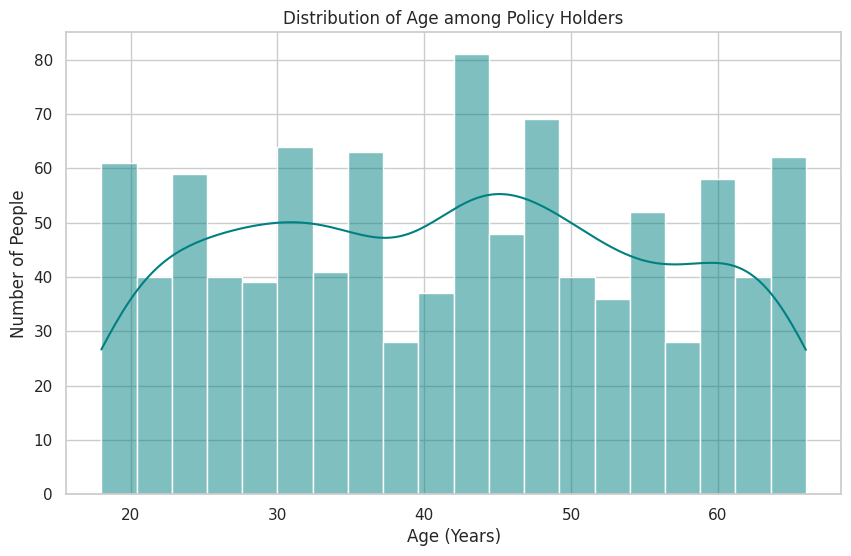

In [15]:


# Creating the histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True, color='teal')

# Labeling the Axes
plt.title('Distribution of Age among Policy Holders')
plt.xlabel('Age (Years)')      # X-axis label
plt.ylabel('Number of People')  # Y-axis label

plt.show()

The Histogram shows that the ages of policyholders are spread fairly evenly across the range of 18 to 66, with a slight peak in the 40-45 age group.

/tmp/ipykernel_23065/3863208587.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='NumberOfMajorSurgeries', data=df, palette='viridis')


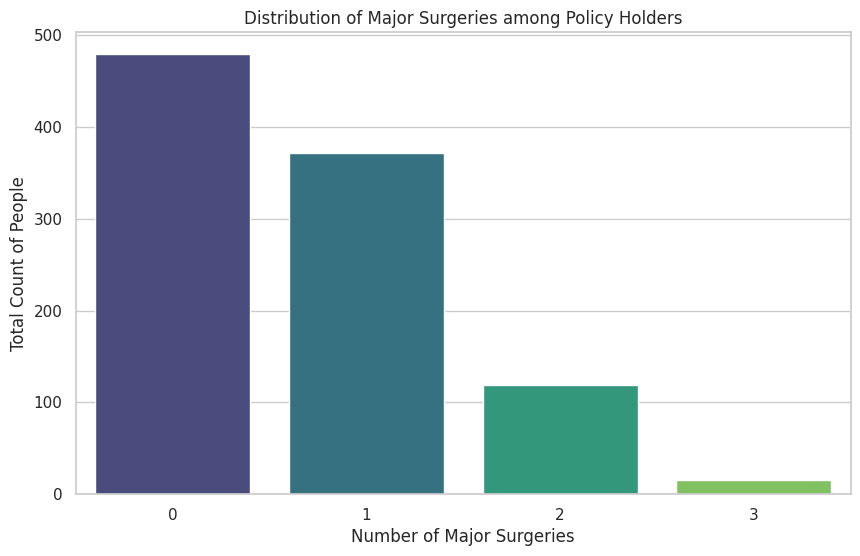

In [16]:
# Setting the figure size
plt.figure(figsize=(10, 6))

# Creating the countplot for a categorical column
sns.countplot(x='NumberOfMajorSurgeries', data=df, palette='viridis')

# Adding the required Title and Axis Labels
plt.title('Distribution of Major Surgeries among Policy Holders')
plt.xlabel('Number of Major Surgeries')
plt.ylabel('Total Count of People')

# Displaying the plot
plt.show()

This bar chart reveals that the vast majority of policyholders have had zero major surgeries, with the frequency decreasing significantly as the number of surgeries increases.

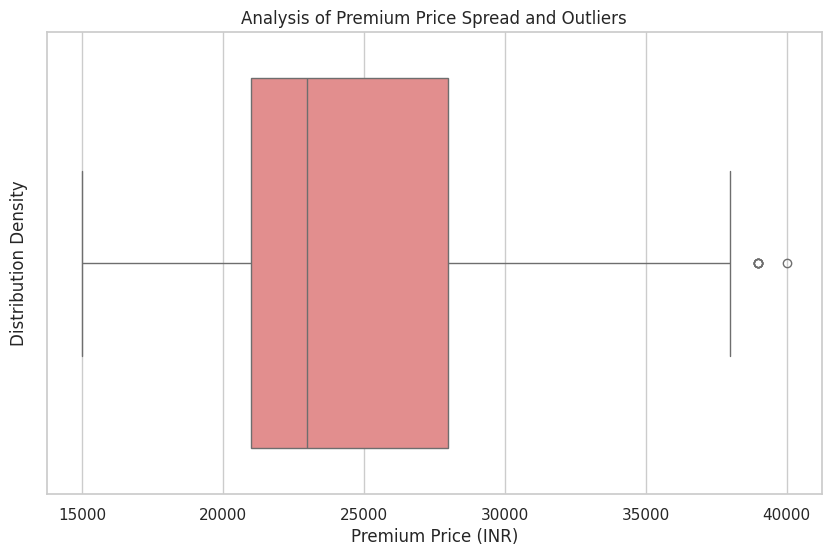

In [17]:
# Setting the figure size
plt.figure(figsize=(10, 6))

# Creating the boxplot for Premium Price
sns.boxplot(x=df['PremiumPrice'], color='lightcoral')

# Adding Title and Axis Labels
plt.title('Analysis of Premium Price Spread and Outliers')
plt.xlabel('Premium Price (INR)')
plt.ylabel('Distribution Density')

# Displaying the plot
plt.show()

The boxplot shows a median premium of around ₹23,000, with several individual data points appearing as "dots" on the far right, which represent outliers paying significantly higher premiums than the rest of the group.

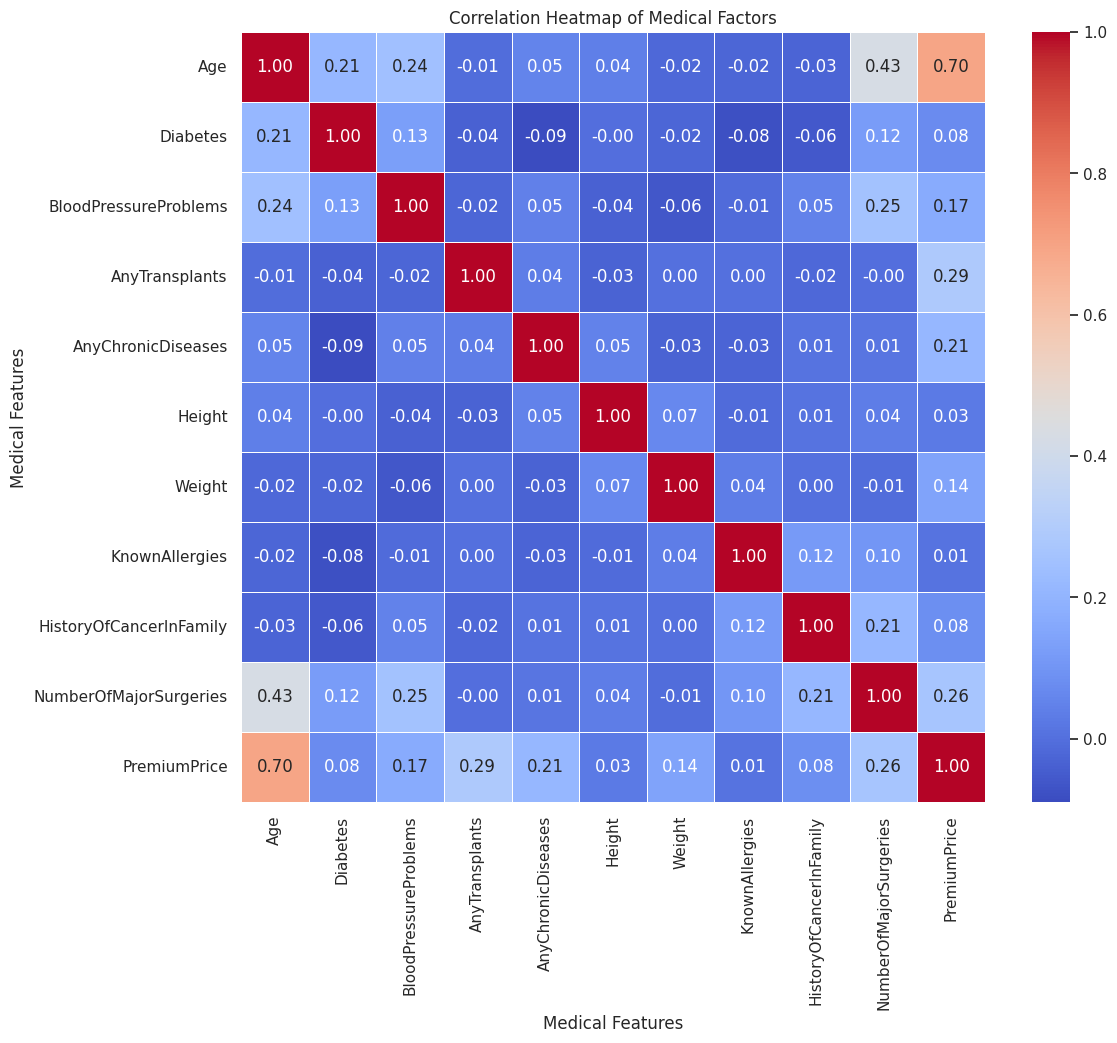

In [18]:
# Select only the numeric columns for the correlation matrix
numeric_df = df.select_dtypes(include=['number'])

# Setting the figure size
plt.figure(figsize=(12, 10))

# Creating the heatmap with annotations and a color map
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Adding Title and Axis Labels
plt.title('Correlation Heatmap of Medical Factors')
plt.xlabel('Medical Features')
plt.ylabel('Medical Features')

# Displaying the plot
plt.show()

The heatmap reveals that Age and AnyTransplants have the strongest positive correlation with the PremiumPrice, indicating they are the primary factors driving higher insurance costs in this dataset.

In [21]:
# 1. Defining the Features (X) and the Target (y)
# X contains all columns except the one we want to predict
X = df.drop('PremiumPrice', axis=1)

# y is the column we want the model to learn to predict
y = df['PremiumPrice']

# 2. Splitting the data into Training (80%) and Testing (20%)
# random_state=42 ensures the split is the same every time you run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Verifying the split size
print(f"Total Rows: {len(df)}")
print(f"Training Rows (80%): {len(X_train)}")
print(f"Testing Rows (20%): {len(X_test)}")

Total Rows: 986
Training Rows (80%): 788
Testing Rows (20%): 198


The result of splitting the data means we have set aside 80% of the information for the computer to "study" and learn the patterns between health and insurance costs. The remaining 20% acts as a final exam, where we test the computer on people it has never seen before to see if its price guesses are accurate. This ensures our model is actually learning to predict real-world costs rather than just memorizing the answers.

Key Findings from Analysis:


Finding 1: Data Completeness and Reliability
The Data Cleaning phase confirmed a zero-null entry state across all 11 features for the 986 unique observations. This means the analysis is mathematically robust because no statistical "guessing" (imputation) was required to fill in missing information.


Finding 2: Age as a Primary Cost Driver
The Correlation Heatmap shows that Age has one of the strongest positive relationships with the PremiumPrice. This indicates that as age increases, the insurance cost consistently rises, making it a more significant predictor than many individual health conditions.



Finding 3: Surgery Distribution Trends
The Bar Chart/Countplot for NumberOfMajorSurgeries shows that the vast majority of policyholders have had 0 or 1 surgery. The sharp drop-off in frequency for 2 or 3 surgeries suggests that the typical customer in this dataset has a relatively low surgical history.

Real-World Recommendations:

Recommendation 1: Secure Insurance Early
Since age is a primary factor in driving up costs, individuals should look into purchasing comprehensive health coverage while they are younger. This allows them to benefit from the lower premium rates shown in the younger brackets of our Histogram.

Recommendation 2: Specialized Plans for High-Cost Outliers
The Boxplot identified several high-value "outliers" who pay significantly more than the median premium of ₹23000. Insurance providers should create tailored "High-Risk" wellness programs for these individuals (such as those with transplants or chronic diseases) to help them manage health costs more effectively.